# Detecting Temporal Subsampling / Aggregation

Many real time series are observed **more slowly than the process actually evolves** — daily snapshots of a system with intraday dynamics, monthly macro data, etc. When a fast VAR(1) process with *contemporaneously independent* innovations is subsampled, the innovations of the slow series become an **aggregate over skipped steps**, which makes the VAR residuals **contemporaneously correlated** across variables (Gong et al., ICML 2015).

`causalts.utils.detect_subsampling` tests for exactly this signature:

> significant contemporaneous correlation in VAR residuals ⟹ temporal aggregation / subsampling is a *candidate* explanation.

**Honesty caveat (Danks & Plis 2013/2014).** Residual contemporaneous correlation is **necessary but not sufficient**. Genuine instantaneous causation and true latent confounding produce the *same* signature and are not separable from a single slow-sampled series by any local test. So the detector returns a **flag + evidence**, not a proof.


## Setup — a fast VAR(1) we can subsample

We simulate a stable VAR(1) with i.i.d. (contemporaneously independent) Student-t innovations, then observe it at different sampling rates `k`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.utils import detect_subsampling, DetectionResult


def random_stable_A(d, seed, spectral_radius=0.7, density=0.3, self_loop=0.3):
    rng = np.random.default_rng(seed)
    A = np.zeros((d, d))
    mask = rng.random((d, d)) < density
    np.fill_diagonal(mask, False)
    A[mask] = rng.normal(0.0, 1.0, size=mask.sum())
    np.fill_diagonal(A, self_loop)
    eig = np.max(np.abs(np.linalg.eigvals(A)))
    if eig > 0:
        A = A * (spectral_radius / eig)
    return A


def generate_fast(d=5, T=12000, seed=0, burn_in=500):
    """Fast VAR(1) with contemporaneously INDEPENDENT Student-t innovations."""
    rng = np.random.default_rng(seed)
    A = random_stable_A(d, seed=seed)
    total = T + burn_in
    df = 5.0
    e = rng.standard_t(df=df, size=(total, d)) / np.sqrt(df / (df - 2.0))
    X = np.zeros((total, d))
    for t in range(1, total):
        X[t] = A @ X[t - 1] + e[t]
    return X[burn_in:]


def subsample(X, k):
    return X[::k].copy()


fast = generate_fast(d=5, T=12000, seed=0)
print("fast series shape:", fast.shape)


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


fast series shape: (12000, 5)


## 1. A genuinely fast-sampled series is NOT flagged

At `k=1` the residuals are just the i.i.d. innovations — no contemporaneous correlation.

In [2]:
res_k1 = detect_subsampling(subsample(fast, 1), alpha=0.05)
print("verdict          :", res_k1.verdict)
print("flagged          :", res_k1.subsampling_flagged)
print("contemp p-value  : %.3g" % res_k1.contemp_pvalue)
print("max |offdiag r|  : %.3f" % res_k1.max_abs_offdiag_corr)


verdict          : NO AGGREGATION SIGNATURE
flagged          : False
contemp p-value  : 0.237
max |offdiag r|  : 0.021


## 2. A subsampled series IS flagged

At `k=2` each observed step aggregates skipped innovations → residuals become contemporaneously correlated.

In [3]:
res_k2 = detect_subsampling(subsample(fast, 2), alpha=0.05)
print("verdict          :", res_k2.verdict)
print("flagged          :", res_k2.subsampling_flagged)
print("contemp p-value  : %.3g" % res_k2.contemp_pvalue)
print("max |offdiag r|  : %.3f" % res_k2.max_abs_offdiag_corr)
print("sig pairs        : %d / %d" % (res_k2.n_sig_pairs, res_k2.n_pairs))
print()
for note in res_k2.notes:
    print("-", note)


verdict          : SUBSAMPLING/AGGREGATION CANDIDATE
flagged          : True
contemp p-value  : 7.22e-34
max |offdiag r|  : 0.132
sig pairs        : 3 / 10

- VAR(1) residuals are contemporaneously correlated (Bartlett chi2=182.5, dof=10, p=7.22e-34; max|offdiag r|=0.132, 3/10 pairs individually significant). Consistent with temporal aggregation of a faster process.
- NOT proof: instantaneous causation and true latent confounding produce the same signature and are not locally separable (Danks & Plis 2013/2014).
- Residuals are largely non-Gaussian (100% of dims reject normality) -- the regime where Gong (2015) Thm 2 makes the fast transition matrix identifiable in principle.


## 3. The signal grows with the aggregation rate

The off-diagonal residual correlation increases with `k` — more skipped steps means more aggregation.

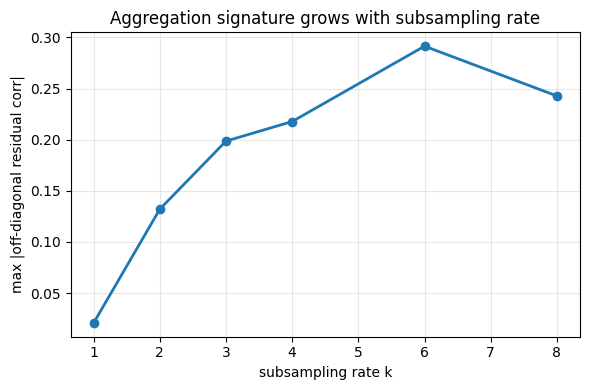

In [4]:
ks = [1, 2, 3, 4, 6, 8]
corrs = [detect_subsampling(subsample(fast, k)).max_abs_offdiag_corr for k in ks]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, corrs, "o-", lw=2)
ax.set_xlabel("subsampling rate k")
ax.set_ylabel("max |off-diagonal residual corr|")
ax.set_title("Aggregation signature grows with subsampling rate")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Short series — use the calibrated bootstrap null

The asymptotic chi-square null is **liberal** when `T` is small relative to `d` (VAR estimation error injects spurious residual correlation). `null="bootstrap"` (the default when `T < 100·d`) reproduces that inflation under H0, keeping the false-positive rate near `alpha`.

In [5]:
# 20 independent k=1 (no-subsampling) short series; bootstrap should rarely false-flag
fp = [
    detect_subsampling(
        subsample(generate_fast(d=10, T=200, seed=s), 1),
        null="bootstrap", n_perm=99,
    ).subsampling_flagged
    for s in range(20)
]
print("bootstrap false-positive rate at T=200, d=10:", np.mean(fp))


bootstrap false-positive rate at T=200, d=10: 0.05


## 5. DataFrame input & reading the result

`detect_subsampling` accepts a `DataFrame` (converted via `.values`). The returned `DetectionResult` carries the full evidence.

In [6]:
df = pd.DataFrame(subsample(fast, 2), columns=[f"x{i}" for i in range(fast.shape[1])])
res = detect_subsampling(df)
print(res)


DetectionResult(contemp_stat=182.4607379537406, contemp_dof=10, contemp_pvalue=7.2235288882425595e-34, max_abs_offdiag_corr=0.13213826231859185, n_sig_pairs=3, n_pairs=10, nongaussian_fraction=1.0, nongaussian_min_p=9.16124244423779e-127, lag=1, alpha=0.05, verdict='SUBSAMPLING/AGGREGATION CANDIDATE', notes=['VAR(1) residuals are contemporaneously correlated (Bartlett chi2=182.5, dof=10, p=7.22e-34; max|offdiag r|=0.132, 3/10 pairs individually significant). Consistent with temporal aggregation of a faster process.', 'NOT proof: instantaneous causation and true latent confounding produce the same signature and are not locally separable (Danks & Plis 2013/2014).', 'Residuals are largely non-Gaussian (100% of dims reject normality) -- the regime where Gong (2015) Thm 2 makes the fast transition matrix identifiable in principle.'])


## Takeaways

- **Flag, not proof.** A positive verdict means *aggregation is a candidate*; instantaneous causation and latent confounding are indistinguishable from a single slow series.
- **Use `lag=1`** — Gong's model implies the subsampled process is still VAR(1).
- **Short series → bootstrap null** (the default via `null="auto"`); large `T` → the fast asymptotic chi-square is fine.
- **Non-Gaussian residuals** (`nongaussian_fraction`) are the regime where the *fast* transition matrix is identifiable in principle (Gong 2015, Thm 2).
